<a href="https://colab.research.google.com/github/pratbharat/-advancecfdwithpratyush/blob/main/1D_conduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Simple Neural Network
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
#Create Neural Network Model = d2T/dx2 = 0
class PINN_Model(nn.Module):
   #Input Layer : 1 -> Output Layer -> 1
   #Hidden -> 3 , 20-> 20-> 20
    def __init__(self,in_feat= 1, h1=20, h2= 20, h3=20, out=1):
        super(PINN_Model, self).__init__()
        self.fc1 = nn.Linear(in_feat,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.fc3 = nn.Linear(h2,h3)
        self.out = nn.Linear(h3,out)
   #RELU= <0 0> linear =>
   #Tanh = Continuous

    def forward(self,x):
        self.activation = nn.Tanh()
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.out(x)
        return x

In [5]:
model = PINN_Model()
print(model)

PINN_Model(
  (fc1): Linear(in_features=1, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=1, bias=True)
)


In [6]:
#Loss  = pde_loss + loss_BC + loss_IC
def pde_residual(model,x):
  #Function = T''(x) + pi^2 * T(x) = 0
  x = x.clone().detach().requires_grad_(True)
  T = model(x)

  #Compute the first order derivative
  T_x = torch.autograd.grad(T,x,grad_outputs=torch.ones_like(T),create_graph=True)[0]

  #Second order derivative
  T_xx = torch.autograd.grad(T_x,x,grad_outputs=torch.ones_like(T_x),create_graph=True)[0]

  #Residual
  residual = T_xx + torch.pi**2 * T
  return residual

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
x_grids = torch.linspace(0,1,100).view(-1,1)
x_grids.shape

torch.Size([100, 1])

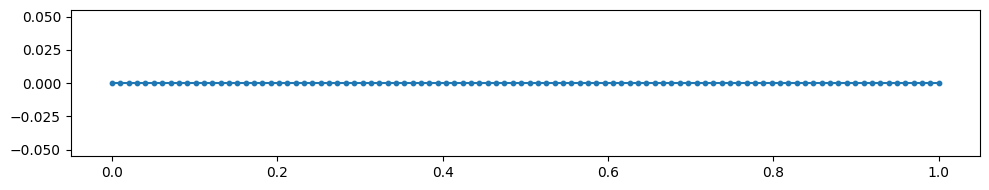

In [14]:
import matplotlib.pyplot as plt
x_np  = x_grids.detach().numpy().flatten()
y_np = torch.zeros_like(x_grids).detach().numpy().flatten()

plt.figure(figsize=(10,2))
plt.plot(x_np,y_np)
plt.scatter(x_np,y_np, s=10)
plt.tight_layout()
plt.show()

In [20]:
x_boundary = torch.tensor([[0.0],[1.0]], dtype= torch.float32)
T_boundary =  torch.zeros_like(x_boundary)

x_interior  = torch.tensor ([[0.5]], dtype= torch.float32)
T_interior = torch.tensor ([[1.0]], dtype= torch.float32)

In [21]:
epochs = 1000
losses = []
wt_pde  = 1.0
wt_BC = 1.0
wt_IC = 1.0

for i in range(epochs):

  res_pde = pde_residual(model,x_grids)
  loss_pde = torch.mean(res_pde**2) #MSE

  T_pred_boundary = model(x_boundary)
  loss_BC = torch.mean((T_pred_boundary - T_boundary)**2)

  T_pred_interior = model(x_interior)
  loss_IC = torch.mean((T_pred_interior - T_interior)**2)

  loss = wt_pde* loss_pde + wt_BC* loss_BC + wt_IC*loss_IC
  losses.append(loss.detach().numpy())

  if i % 50 == 0:
    print(f'Epoch : {i} Loss : {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
print("Training Complete !")


Epoch : 0 Loss : 4.347995758056641
Epoch : 50 Loss : 1.0127655267715454
Epoch : 100 Loss : 1.0029410123825073
Epoch : 150 Loss : 0.9976468086242676
Epoch : 200 Loss : 0.9914776086807251
Epoch : 250 Loss : 0.983681321144104
Epoch : 300 Loss : 0.9725081920623779
Epoch : 350 Loss : 0.9536193013191223
Epoch : 400 Loss : 0.9156014323234558
Epoch : 450 Loss : 0.8273977041244507
Epoch : 500 Loss : 0.6065405607223511
Epoch : 550 Loss : 0.24562737345695496
Epoch : 600 Loss : 0.06863181293010712
Epoch : 650 Loss : 0.027133837342262268
Epoch : 700 Loss : 0.010780198499560356
Epoch : 750 Loss : 0.005691927392035723
Epoch : 800 Loss : 0.0045195696875452995
Epoch : 850 Loss : 0.0027608664240688086
Epoch : 900 Loss : 0.0021612143609672785
Epoch : 950 Loss : 0.0018296217313036323
Training Complete !


Text(0.5, 0, 'Epochs')

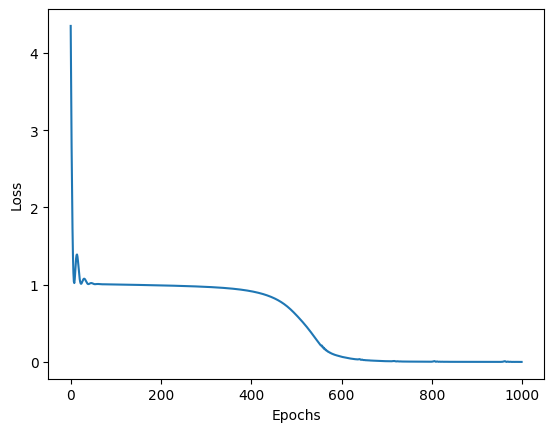

In [22]:
import matplotlib.pyplot as plt
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')

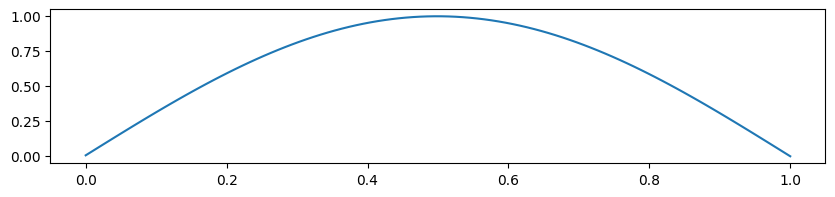

In [23]:
x_test = torch.linspace(0,1,100).view(-1,1)
T_pred = model(x_test)

x_np  = x_test.detach().numpy().flatten()
y_np = T_pred.detach().numpy().flatten()

plt.figure(figsize=(10,2))
plt.plot(x_np,y_np)

In [24]:
# Excercise : We have heat generation sourch at x = 0.5 , q = 10 watt/sec ; We take transient problem
# Create a PINN model for the same
# 2 input: x,t
# Output : T
# pde_residual (mode,x,t, q)
# BC_residuual (x=0, x=1)
